      ตารางเปรียบเทียบผลลัพธ์ของแบบจำลอง (Summary)
Metric          | Simple LR (1 PC)     | Multiple LR (30 PCs)
--------------------------------------------------------------
MAE (ปี)        | 12.65                | 12.73               
RMSE (ปี)       | 14.49                | 14.53               
R² Score        | -0.0107              | -0.0153             


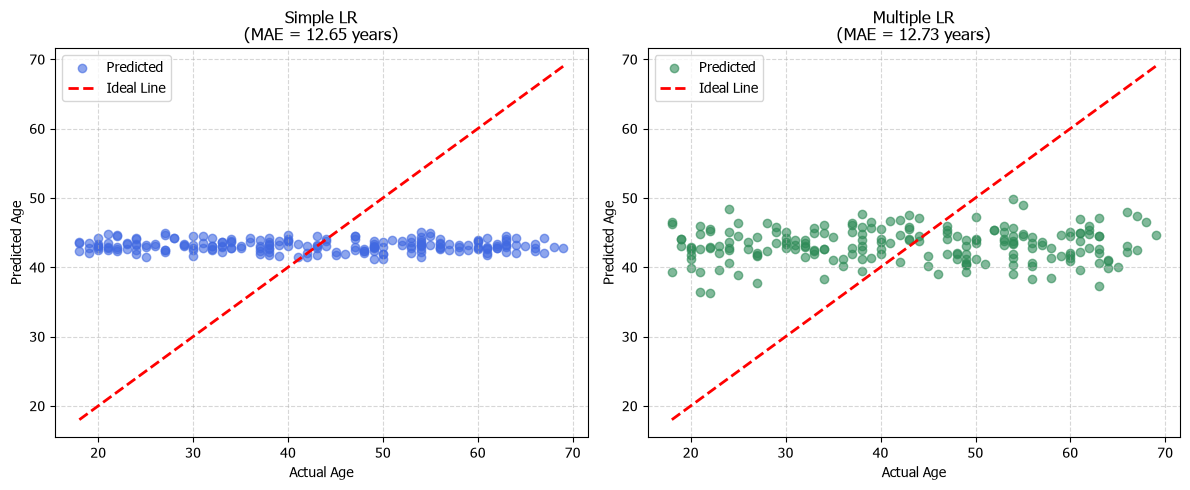

In [1]:
# -*- coding: utf-8 -*-
"""
LAB 1: Regression (Age Prediction from Facial Features)
- Simple Linear Regression
- Multiple Linear Regression
- Dimension Reduction via PCA
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ตั้งค่าฟอนต์ภาษาไทยสำหรับ Matplotlib เพื่อป้องกัน Warning เรื่อง Glyph Missing
plt.rcParams['font.sans-serif'] = ['Tahoma', 'Garuda', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

def main():
    # 1. จำลองข้อมูล
    np.random.seed(42)
    X_raw = np.random.rand(1000, 4096) 
    y = np.random.randint(18, 70, size=1000)
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)

    # 2. ลดมิติข้อมูลด้วย PCA
    n_components = 30
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)

    # 3. แบ่งข้อมูล Train / Test
    X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

    # 4. Simple Linear Regression (ใช้แค่ PC1)
    X_train_simple = X_train[:, 0].reshape(-1, 1)
    X_test_simple = X_test[:, 0].reshape(-1, 1)
    
    simple_model = LinearRegression()
    simple_model.fit(X_train_simple, y_train)
    y_pred_simple = simple_model.predict(X_test_simple)
    
    mae_simple = mean_absolute_error(y_test, y_pred_simple)
    rmse_simple = np.sqrt(mean_squared_error(y_test, y_pred_simple))
    r2_simple = r2_score(y_test, y_pred_simple)

    # 5. Multiple Linear Regression (ใช้ครบ 30 PCs)
    multiple_model = LinearRegression()
    multiple_model.fit(X_train, y_train)
    y_pred_multiple = multiple_model.predict(X_test)
    
    mae_multiple = mean_absolute_error(y_test, y_pred_multiple)
    rmse_multiple = np.sqrt(mean_squared_error(y_test, y_pred_multiple))
    r2_multiple = r2_score(y_test, y_pred_multiple)
    
    # แสดงเฉพาะตารางสรุปผลลัพธ์
    print("==================================================")
    print("      ตารางเปรียบเทียบผลลัพธ์ของแบบจำลอง (Summary)")
    print("==================================================")
    print(f"{'Metric':<15} | {'Simple LR (1 PC)':<20} | {'Multiple LR (30 PCs)':<20}")
    print("-" * 62)
    print(f"{'MAE (ปี)':<15} | {mae_simple:<20.2f} | {mae_multiple:<20.2f}")
    print(f"{'RMSE (ปี)':<15} | {rmse_simple:<20.2f} | {rmse_multiple:<20.2f}")
    print(f"{'R² Score':<15} | {r2_simple:<20.4f} | {r2_multiple:<20.4f}")
    print("==================================================")
    
    # 6. พล็อตกราฟเปรียบเทียบ
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.scatter(y_test, y_pred_simple, color='royalblue', alpha=0.6, label='Predicted')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Line')
    plt.title(f"Simple LR\n(MAE = {mae_simple:.2f} years)")
    plt.xlabel("Actual Age")
    plt.ylabel("Predicted Age")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.subplot(1, 2, 2)
    plt.scatter(y_test, y_pred_multiple, color='seagreen', alpha=0.6, label='Predicted')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Line')
    plt.title(f"Multiple LR\n(MAE = {mae_multiple:.2f} years)")
    plt.xlabel("Actual Age")
    plt.ylabel("Predicted Age")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()